In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score,precision_score,recall_score,f1_score

In [4]:
df = pd.read_csv("emails.csv")
print("Dataset loaded successfully")
print(df.info())
print(df.head())

Dataset loaded successfully
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), object(1)
memory usage: 118.5+ MB
None
  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0            

In [5]:
df = df.drop(columns=['Email No.'])
df = df.dropna()

In [6]:
X = df.drop(columns=['Prediction'])
y = df['Prediction']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)

In [14]:
svm = SVC(kernel='linear',random_state = 42)
svm.fit(X_train,y_train)
y_pred_svm = svm.predict(X_test)


=====KNN Model Evaluation=====
Confusion Matrix:
 [[707  32]
 [ 23 273]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96       739
           1       0.90      0.92      0.91       296

    accuracy                           0.95      1035
   macro avg       0.93      0.94      0.94      1035
weighted avg       0.95      0.95      0.95      1035

Accuracy: 0.9468599033816425
Precision: 0.8950819672131147
Recall: 0.9222972972972973
F1 Score:  0.908485856905158

=====SVM Model Evaluation=====
Confusion Matrix:
 [[707  32]
 [ 23 273]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96       739
           1       0.90      0.92      0.91       296

    accuracy                           0.95      1035
   macro avg       0.93      0.94      0.94      1035
weighted avg       0.95      0.95      0.95      1035

Accuracy: 0.9468599033816425
Precis

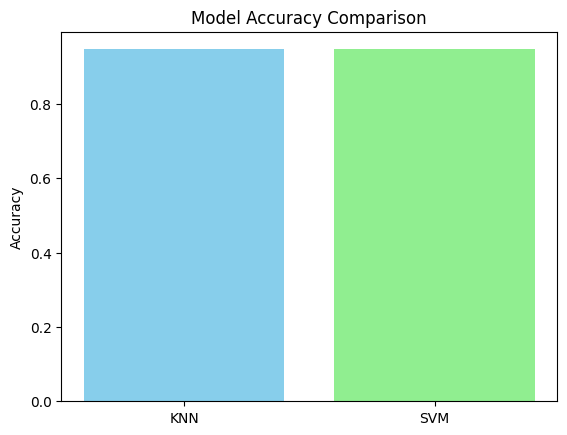

In [16]:
def evaluate_model(name,y_test,y_pred):
    print(f"\n====={name} Model Evaluation=====")
    print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
    print("Classification Report:\n",classification_report(y_test,y_pred))
    print("Accuracy:",accuracy_score(y_test,y_pred))
    print("Precision:",precision_score(y_test,y_pred))
    print("Recall:",recall_score(y_test,y_pred))
    print("F1 Score: ",f1_score(y_test,y_pred))

evaluate_model("KNN",y_test,y_pred_knn)
evaluate_model("SVM",y_test,y_pred_svm)

models = ['KNN', 'SVM']
accuracy = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_svm)
]

plt.bar(models, accuracy, color=['skyblue', 'lightgreen'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()